# Building a Predictive Model

## Import Necessary Libraries

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [68]:
df = pd.read_csv("clean_train.csv")

## Handle Encoding

In [69]:
non_numerical = df.select_dtypes(include=['object']).columns
print(non_numerical)

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')


In [70]:
df.select_dtypes(include=['object']).shape[1]

39

In [71]:
df.shape

(1460, 76)

Out of 76 columns of the dataset, there are 39 categorical columns.

### Checking correlation of Categorical Columns

In [72]:
cat_cols = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
            'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
            'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
            'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
            'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
            'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
            'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
            'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']

In [73]:
df_encoded = pd.get_dummies(df, columns=cat_cols)

This code creates a derived dataset(df_encoded) containing the encoded categorical features of the original dataset(df).

This way, the original dataset(df) stays the same

In [74]:
cat_correlation = df_encoded.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

In [75]:
print(cat_correlation[:38])

SalePrice                1.000000
OverallQual              0.790982
GrLivArea                0.708624
GarageCars               0.640409
GarageArea               0.623431
TotalBsmtSF              0.613581
1stFlrSF                 0.605852
FullBath                 0.560664
BsmtQual_Ex              0.553105
TotRmsAbvGrd             0.533723
YearBuilt                0.522897
YearRemodAdd             0.507101
KitchenQual_Ex           0.504094
Foundation_PConc         0.497734
GarageYrBlt              0.486362
MasVnrArea               0.472614
Fireplaces               0.466929
ExterQual_Gd             0.452466
ExterQual_Ex             0.451164
BsmtFinType1_GLQ         0.434597
HeatingQC_Ex             0.434543
GarageFinish_Fin         0.419678
Neighborhood_NridgHt     0.402149
BsmtFinSF1               0.386420
SaleType_New             0.357509
SaleCondition_Partial    0.352060
FireplaceQu_Gd           0.339329
GarageType_Attchd        0.335961
LotFrontage              0.334771
MasVnrType_Sto

In [76]:
print(cat_correlation[-7:])

HeatingQC_TA        -0.312677
Foundation_CBlock   -0.343263
GarageType_Detchd   -0.354141
GarageFinish_Unf    -0.410608
BsmtQual_TA         -0.452394
KitchenQual_TA      -0.519298
ExterQual_TA        -0.589044
Name: SalePrice, dtype: float64


After encoding categorical columns and checking their correlation with SalePrice, observation shows that categorical columns have stronger correlations than expected. To highlight a few, ExterQual_TA (-0.59) and KitchenQual_TA (-0.52) showed strong negative correlations, indicating that average quality ratings are reliable predictors of lower sale prices.

## Building the Model

### Feature Selection

In [77]:
feature_cols = ['OverallQual', 'GrLivArea',
    'TotalBsmtSF', '1stFlrSF', 'FullBath',
    'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd',
    'MasVnrArea', 'Fireplaces',
    'WoodDeckSF', '2ndFlrSF', 'OpenPorchSF',
    'BsmtQual_Ex', 'KitchenQual_Ex', 'Foundation_PConc',
    'ExterQual_Gd', 'HeatingQC_Ex', 'Neighborhood_NridgHt',
    'SaleType_New', 'SaleCondition_Partial', 'FireplaceQu_Gd',
    'LotFrontage', 'MasVnrType_Stone', 'Neighborhood_NoRidge',
    'KitchenQual_Gd', 'ExterQual_TA', 'KitchenQual_TA',
    'BsmtQual_TA', 'GarageFinish_Unf', 'Foundation_CBlock', 'HeatingQC_TA'
]

These 44 features were selected based of the their correlation to the target feature. It is a mix of negatively correlated and positively correlated features below -0.3 and above 0.3 respectively. Redundant features describing the same attribute were dropped to avoid multicollinearity.

### Training and Testing Set

In [78]:
X = df_encoded[feature_cols]
y = df['SalePrice']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

The dataset was split into 80% training set and 20% testing set. The training set is used to train the model, while the testing set is used to evaluate the model's performance. A random state of 42 is used to ensure reproductibility.

In [80]:
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (1168, 32)
Testing set size: (292, 32)


Now that the dataset has been split, two models will be built and compared. A Linear Regression model, and a Random Forest Model.

### Linear Regression Model

In [81]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [82]:
y_pred = lr_model.predict(X_test)

In [83]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr = r2_score(y_test, y_pred)

print(f"Linear Regression RMSE: ${rmse_lr:,.0f}")
print(f"Linear Regression R² Score: {r2_lr:.4f}")

Linear Regression RMSE: $34,160
Linear Regression R² Score: 0.8479


The Linear Regression model achieved an R² score of 0.8479, meaning it explains approximately 85% of the variation in SalePrice. The RMSE of 34,160 USD indicates that predictions are off by an average of 34,160 USD, which is reasonable given the wide price range in the dataset (34,900 USD to 755,000 USD).

### Random Forest Model


In [84]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [85]:
y_pred2 = rf_model.predict(X_test)

In [89]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred2))
r2_rf = r2_score(y_test, y_pred2)

print(f"Random Forest RMSE: ${rmse_rf:,.0f}")
print(f"Random Forest R² Score: {r2_rf:.4f}")

Random Forest RMSE: $30,244
Random Forest R² Score: 0.8807


The Random Forest model achieved an R² score of 0.8807, meaning it explains approximately 88% of the variation in SalePrice. The RMSE of 30,244 USD indicates that predictions are off by an average of 30,244 USD.

### Comparison of the two Models.

Although both models performed very well, Random Forest outperformed Linear Regression on both metrics (RMSE & R²).

The Random Forest Model achieved an RMSE of 30,244 USD compared to 34,160 USD achieved by the Linear Regression Model.

The Random Forest Classifier achieved an R² score of 0.8807 compared to 0.8479, which was what the Linear Regression model got.

This improvement is expected as Random Forest builds multiple decision trees and averages their predictions, making it more robust to outliers and complex relationships in the data. The final Random Forest model explains approximately 88% of the variation in SalePrice, with predictions off by an average of 30,244 USD.

### Visualize Actual vs Predicted Prices

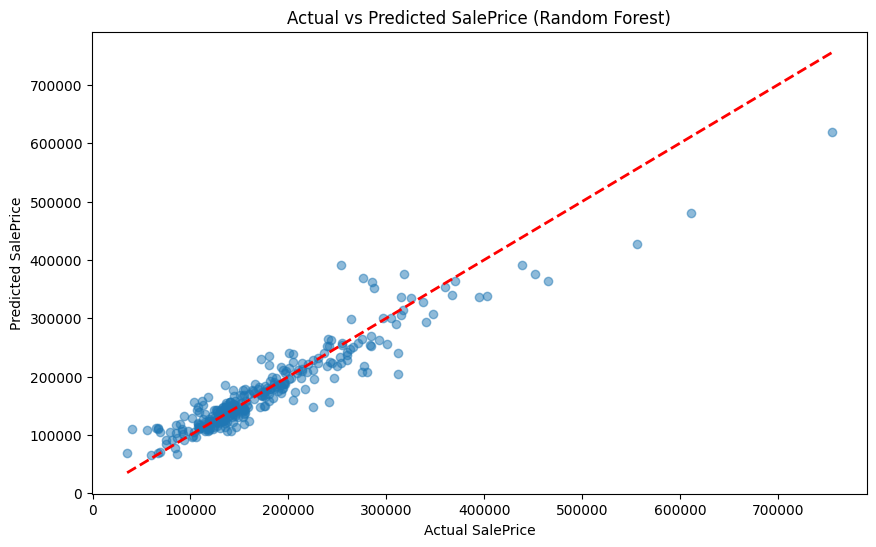

In [87]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred2, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice (Random Forest)')
plt.show()

The plot shows that the prices predicted by the model are very close to the actual prices in the dataset, except when it comes to predicting the prices of higher luxury houses, which the dataset did not have a lot of information on.

The model performs well for moderately priced homes between 50,000 USD and 300,000 USD, where predictions closely follow the ideal line. However accuracy decreases for higher value properties above 400,000 USD, consistent with the outliers identified during data cleaning and pre-processing.

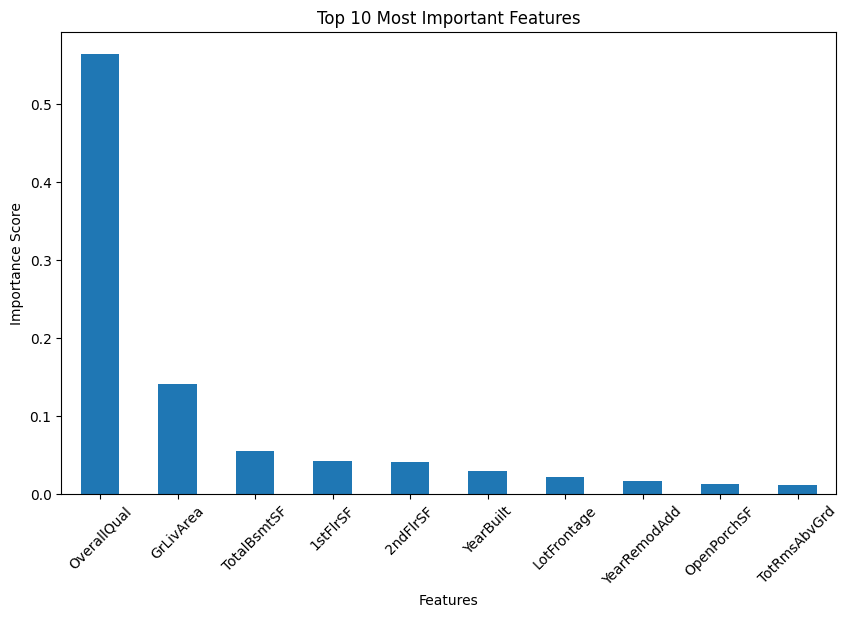

In [88]:
importance = pd.Series(rf_model.feature_importances_,
                       index=feature_cols).sort_values(ascending=False)[:10]

plt.figure(figsize=(10, 6))
importance.plot(kind='bar')
plt.title('Top 10 Most Important Features')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.show()

The feature importance chart confirms that OverallQual is by far the most influential predictor, accounting for more than 50% of the model's decision making. GrLivArea follows at more than 10%, while remaining features each contribute less than 10% individually.

## In Summary

The Random Forest model achieved an R² of 0.8817 and RMSE of 30,244 USD, outperforming Linear Regression. The model is most reliable for mid-range properties and less accurate for luxury homes, which represent a small portion of the dataset.